---
title: "3D Forward Simulation for Sheet-Like Conductors Part 2"
subtitle: "Delaunay surface models"
authors:
  - id: devincowan
---

```{admonition} Advanced notebook
:class: danger
This tutorial focusses on advanced functionality within SimPEG. Basic and intermediate level functionality are not discussed in detail, as we assume the user is already an experienced SimPEG user.
```

```{admonition} Medium-weight notebook
:class: caution
Requires moderate computational resources. Run-times may exceed several minutes and require up to 8 GB of available RAM.
```

```{admonition} Prerequisite Tutorials
:class: note
* [Fundamentals of Finite Volume for TDEM Simulations](fwd_tdem_fundamentals.ipynb
* [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb)
* [3D Forward Simulation for Sheet-Like Conductors Part 1](fwd_utem_hierarchical_3d_part_1.ipynb)
```

**Keywords:** Forward simulation, hierarchical finite volume, sheet-like conductor, Delaunay conductance model.

</br>

**Summary:** This is part 2 of a 2 part tutorial for simulating TDEM data in the presence of sheet-like conductors within a 3D host. In [part 1](fwd_utem_hierarchical_3d_part_1.ipynb) we considered rectangular plate conductors within a 3D host. Here, we demonstrate how a Delaunay surface can be used to parameterize the electrical properties of an inhomogeneous sheet-like conductor with an irregular geometry. We employ a hierarchical finite volume approach, which parameterizes thick structures as cell conductivities ($\sigma$), sheet-like conductors as face conductances ($\xi_x, \xi_y, \xi_z$), and wire-like conductors as edge integrated conductances ($\lambda_x, \lambda_y, \lambda_z$); see the figure below. Data are simulated for the borehole UTEM survey geometry presented in the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial. Functionality used to simulate the data is imported from the [simpeg.electromagnetics.time_domain](xref:simpeg#simpeg.electromagnetics.time_domain) module.

</br>

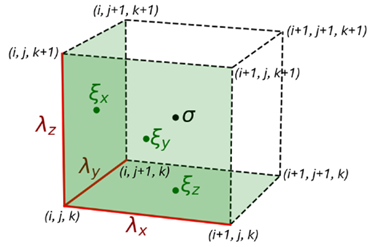

</br>

**Learning Objectives:**

- Defining a Delaunay conductance model
- Mapping the Delaunay conductance model to the faces of a mesh

## Importing Modules

Here, we import all of the functionality required to run the notebook for the tutorial exercise. All of the functionality specific to TDEM is imported from [simpeg.electromagnetics.time_domain](xref:simpeg#simpeg.electromagnetics.time_domain).
We also import some useful utility functions from [simpeg.utils](xref:simpeg#simpeg.utils).

In [1]:
# SimPEG functionality
import simpeg.electromagnetics.time_domain as tdem
from simpeg import maps
from simpeg.utils import plot2Ddata, get_default_solver

# discretize functionality
from discretize import TreeMesh, SimplexMesh
from discretize.utils import mkvc, ndgrid, active_from_xyz

# Common Python functionality
import numpy as np
from scipy.spatial import Delaunay, cKDTree
from scipy.interpolate import LinearNDInterpolator
from scipy.constants import mu_0
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d.art3d import PolyCollection, Poly3DCollection

import sys, os
sys.path.append(r"D:\Documents\Python\my_supporting_functions")
from my_plate_utils import (
    get_face_projection_simplex,
)
from my_waveform_utils import TriangularUTEMWaveform
from my_field_utils import computeH0

mpl.rcParams.update({"font.size": 14})

write_output = False  # Optional

## Defining the Topography

Here, we reuse the valley-like topography from the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) and [3D Forward Simulation for Sheet-Like Conductors Part 1](fwd_utem_hierarchical_3d_part_1.ipynb) tutorials.

In [2]:
# Generate or load topography
x_topo, y_topo = np.meshgrid(
    np.linspace(-2100, 2100, 141), np.linspace(-2100, 2100, 141)
)
z_topo = 300.0 + 100.0 * (1 / np.pi) * (
    np.arctan((x_topo - 500 * np.sin(np.pi * y_topo / 2800) - 1000.0) / 300.0)
    - np.arctan((x_topo - 500 * np.sin(np.pi * y_topo / 2800) + 1000.0) / 300.0)
)

In [3]:
# Turn into a (N, 3) numpy.ndarray
x_topo, y_topo, z_topo = mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)
topo_xyz = np.c_[mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)]

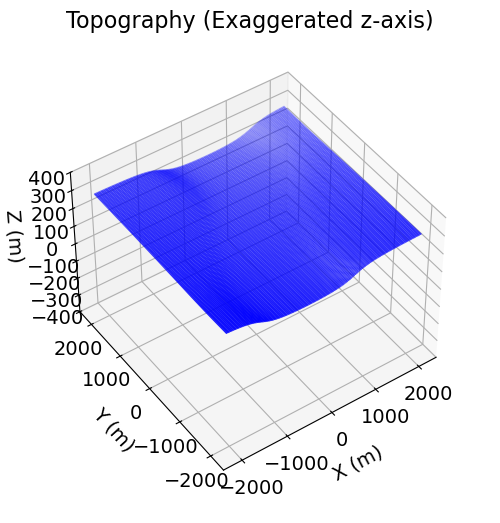

In [4]:
# Plot the topography
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_zlim([-400, 400])
ax.scatter3D(topo_xyz[:, 0], topo_xyz[:, 1], topo_xyz[:, 2], s=0.25, c="b")
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=-20)
ax.view_init(elev=45.0, azim=-125)

## Defining the (UTEM) Survey

The objects required to define a TDEM survey within SimPEG are discussed in the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial.

**For this tutorial**, define the same survey geometry that was used in the [3D Forward Simulation for Sheet-Like Conductors Part 1](fwd_utem_hierarchical_3d_part_1.ipynb) tutorial. We simulate borehole University of Toronto electromagnetic (UTEM) data for a single transmitter loop. Some basic information regarding UTEM survey geometry and its data can be found [here](https://giftoolscookbook.readthedocs.io/en/latest/content/comprehensive_workflow/utem/1_basic_anomalies.html). The transmitter loop is square with a side length of 1200 m. The operating frequency of the UTEM waveform is 1 Hz. db/dt sensors are used to measure 3-component data for a highly-regulated triangular waveform with a 100% duty cycle. db/dt sensors are located within a borehole at (x, y) = (80 m, 20 m) that extends 800 m vertically below the Earth's surface.

#### Defining Survey Parameters

In [5]:
# WAVEFORM PROPERTIES
operating_frequency = 1.0  # Operating frequency
I_max = 1.0  # Maximum current amplitude

# TRANSMITTER LOOP PROPERTIES
loop_width = 1200

# RECEIVER LOCATIONS
x_bh, y_bh = 80., 20.           # horizontal position
ds = 25.0                       # receiver spacing
s_max = topo_xyz[:, -1].min()   # top receiver
s_min = s_max - 800.            # bottom receiver

# TIME CHANNELS
period = 1 / operating_frequency
time_channels = (period / 4) * 2 ** np.linspace(-7, 0, 8)

#### Defining the Waveform

We use the same waveform from the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial. Again, the ``TriangularUTEMWaveform`` class is used to define the highly regulated 100\% duty cycle triangular waveform.

In [6]:
utem_waveform = TriangularUTEMWaveform(operating_frequency)

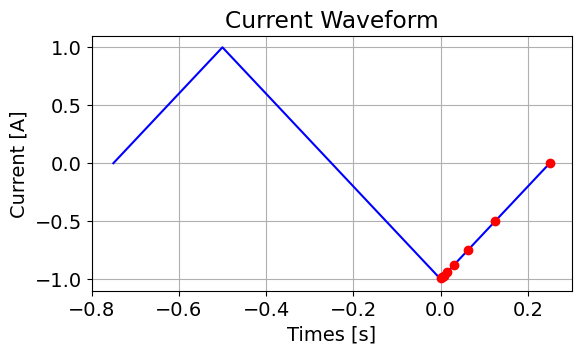

In [7]:
fig = plt.figure(figsize=(6, 3))

ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.85])
plot_times = np.linspace(-0.75 * period, 0.25 * period, 25)
ax1.plot(
    plot_times,
    [utem_waveform.eval(t) for t in plot_times],
    "b"
)
ax1.plot(
    time_channels,
    [utem_waveform.eval(t) for t in time_channels],
    "ro"
)
ax1.grid()
ax1.set_xlabel("Times [s]")
ax1.set_ylabel("Current [A]")
ax1.set_title("Current Waveform")

plt.show()

#### Defining the Source, Receiver and Survey Objects

The general approach for generating TDEM surveys is detailed in the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial. **For this tutorial,** we use the same geometry that was used in the [3D Forward Simulation for Sheet-Like Conductors Part 1](fwd_utem_hierarchical_3d_part_1.ipynb) tutorial. db/dt receivers within the borehole measure the fields according to a borehole-centric coordinate system. The borehole-centric coordinate system is defined as follows:
* *Strike direction (U):* which in this case is in the Northing direction
* *Dip direction (V):* which in this case is in the Easting direction
* *Downhole direction (A):* which in this case is in the down direction

```{admonition} Note
:class: note
For real-world problems, boreholes are not perfectly vertical, as resolving near-vertical borehole orientation becomes challenging.
``` 

In [8]:
# Necessary to define transmitter on surface topography
topo_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)

In [9]:
# Define the transmitter loop using 50 m segments.
# Necessary to discretize along wire path.
half_width = 0.5 * loop_width
u = np.arange(-half_width, half_width, 50.0)
v = half_width * np.ones_like(u)

xtx = np.r_[u, v, -u, -v, -half_width]
ytx = np.r_[-v, u, v, -u, -half_width]
ztx = topo_interp(np.c_[xtx, ytx])
xyz_loop = np.c_[xtx, ytx, ztx]

In [10]:
# Define the borhole receiver locations
z_bh = np.arange(s_min, s_max+ds, ds)
receiver_locations = ndgrid(x_bh, y_bh, z_bh)

In [11]:
# Define the orientations for the U, V and A receivers
orientations_list = [
    np.r_[0, 1, 0],
    np.r_[1, 0, 0],
    np.r_[0, 0, -1]
]

# Define U, V, A receivers
receivers_list = [
    tdem.receivers.PointMagneticFluxTimeDerivative(
        receiver_locations, time_channels, orientation=orient
    ) for orient in orientations_list
]

# Define the loop source
source_list = [
    tdem.sources.LineCurrent(
        receivers_list, location=xyz_loop, waveform=utem_waveform
    )
]

# Define the survey
survey = tdem.Survey(source_list)

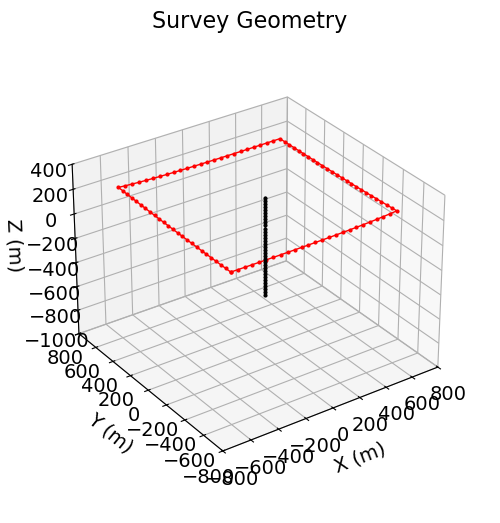

In [12]:
# Plot the survey geometry
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_xlim([-800, 800])
ax.set_ylim([-800, 800])
ax.set_zlim([-1000, 400])
ax.plot(xyz_loop[:, 0], xyz_loop[:, 1], xyz_loop[:, 2], "r-o", lw=1, markersize=2)
ax.plot(
    receiver_locations[:, 0],
    receiver_locations[:, 1],
    receiver_locations[:, 2],
    "k-o",
    lw=1,
    markersize=2
)
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Survey Geometry", fontsize=16, pad=-20)
ax.view_init(elev=30.0, azim=-125)

## Defining a Delaunay Conductance Model

Delaunay surfaces can be used to discretely represent continuous 3D surfaces. Delaunay surfaces are frequently comprised of a set of triangles, which are stored using a set of vertices and simplices. Here, we show how a 3D Delaunay surface can be used to represent the shape of a sheet-like conductor with non-trivial geometry. Inhomogeneous electrical properties can be captured by assigning a different conductance value to each triangle in the Delaunay surface. The set of conductances for all Delaunay triangles represents the Delaunay conductance model.

#### Defining a Local Delaunay Surface 

It can be challenging to assign model parameter values (conductances) over a 3D Delaunay surface directly. So instead, we will generate a 2D Delaunay surface within a local coordinate system, assign the model parameter values according to each triangle in the 2D Delaunay surface, then warp/shift/rotate the 2D Delaunay surface to generate the 3D Delaunay surface for the sheet-like target.

**For this tutorial,** we create a Delaunay surface on the xy-plane centered at the origin from a set of uniformly spaced points (vertices) within a square region. The region has a side length of 480 m and the spacing is 40 m.

In [13]:
temp_width = 480.  # width of the local square region
ds = 40.           # sampling distance

In [14]:
# Define the set of xy points (vertices)
dlny_pts_2d = ndgrid(
    np.arange(-temp_width/2, temp_width/2+ds, ds),
    np.arange(-temp_width/2, temp_width/2+ds, ds),
)

# Define the simplices
dlny_ids = np.arange(len(dlny_pts_2d))

k1 = (dlny_pts_2d[:, 0] < np.max(dlny_pts_2d[:, 0])) & (dlny_pts_2d[:, 1] < np.max(dlny_pts_2d[:, 1]))
k2 = (dlny_pts_2d[:, 0] > np.min(dlny_pts_2d[:, 0])) & (dlny_pts_2d[:, 1] < np.max(dlny_pts_2d[:, 1]))
k3 = (dlny_pts_2d[:, 0] < np.max(dlny_pts_2d[:, 0])) & (dlny_pts_2d[:, 1] > np.min(dlny_pts_2d[:, 1]))
k4 = (dlny_pts_2d[:, 0] > np.min(dlny_pts_2d[:, 0])) & (dlny_pts_2d[:, 1] > np.min(dlny_pts_2d[:, 1]))

dlny_simps = np.vstack([
    np.c_[dlny_ids[k1], dlny_ids[k2], dlny_ids[k3]],
    np.c_[dlny_ids[k2], dlny_ids[k3], dlny_ids[k4]]
])

The local 2D Delaunay surface is plotted below.

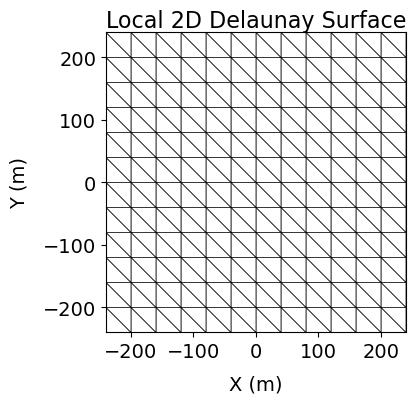

In [15]:
poly_tris = PolyCollection(dlny_pts_2d[dlny_simps])
poly_tris.set_facecolor('w')
poly_tris.set_edgecolor('k')
poly_tris.set_linewidth(0.5)

fig = plt.figure(figsize=(4, 4))
ax1 = fig.add_axes([0.1, 0.1, 0.75, 0.75])

ax1.add_collection(poly_tris)
ax1.set_xlim([dlny_pts_2d[:, 0].min(), dlny_pts_2d[:, 0].max()])
ax1.set_ylim([dlny_pts_2d[:, 1].min(), dlny_pts_2d[:, 1].max()])
ax1.set_xlabel("X (m)", labelpad=10)
ax1.set_ylabel("Y (m)", labelpad=10)
ax1.set_title("Local 2D Delaunay Surface", fontsize=16, pad=-20)

plt.show()

### Defining the Delaunay Conductance Model

Here we define the Delaunay conductance model in the local 2D coordinate system, where each triangle is assigned a conductance value.

**For the tutorial,** the spatial distribution is define by a 2D Gaussian centered at (20 m, 40 m), standard deviations of 80 m along x and 160 m along y, with an amplitude of 1e5 S. Parameter values are defined according to the function value at the center of each triangle.

In [16]:
# Compute the center location of each triangle
dlny_centers_2d = np.zeros((len(dlny_simps), 2))
for ii in range(2):
    dlny_centers_2d += dlny_pts_2d[dlny_simps[:, ii], :] / 3.

# Define the Delaunay conductance model using the function
dlny_conductance_model = 1e5 * np.exp(
    -(dlny_centers_2d[:, 0] - 20)**2/80**2 - (dlny_centers_2d[:, 1] - 40.)**2/160**2
)

Below we plot the spatial distribution of conductances over the local 2D Delaunay surface.

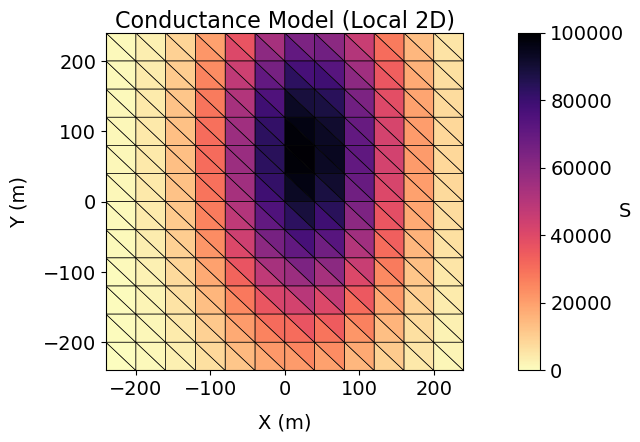

In [17]:
cmap = mpl.cm.magma_r
norm = mpl.colors.Normalize(vmin=0, vmax=1e5)

poly_tris = PolyCollection(dlny_pts_2d[dlny_simps])
poly_colors = cmap(norm(dlny_conductance_model))
poly_tris.set_facecolor(poly_colors)
poly_tris.set_edgecolor('black')  # Set to 'none' if you want a smooth look without wireframes
poly_tris.set_linewidth(0.5)

fig = plt.figure(figsize=(5.5, 4.5))
ax1 = fig.add_axes([0.1, 0.1, 0.65, 0.75])
ax2 = fig.add_axes([0.85, 0.1, 0.04, 0.75])

ax1.add_collection(poly_tris)
ax1.set_xlim([dlny_pts_2d[:, 0].min(), dlny_pts_2d[:, 0].max()])
ax1.set_ylim([dlny_pts_2d[:, 1].min(), dlny_pts_2d[:, 1].max()])
ax1.set_xlabel("X (m)", labelpad=10)
ax1.set_ylabel("Y (m)", labelpad=10)
ax1.set_title("Conductance Model (Local 2D)", fontsize=16, pad=-20)

cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.magma_r
)
cbar.set_label("S", rotation=0, labelpad=0)

plt.show()

### Generating the 3D Delaunay Surface

Here, we warp/rotate/shift the local 2D Delaunay surface to generate the 3D Delaunay surface representing the geometry of the sheet-like conductor. There are several things to note here:
* when instantiating the set of 3D points, we must add a z-coordinate
* the ordering of the triangles (simplices), and thus the model parameter values, DOES NOT CHANGE!

**For the tutorial,** we first define a flat surface on the xy-plane centered at the origin. The surface is warped using a sinuisoid with an amplitude of 100 m. The surface is then rotated 30 degrees counterclockwise about the y-axis, then shifted 200 m vertically downward.

In [18]:
# Instantial the 3D Delaunay surface by adding a z-coordinate
dlny_pts_3d = np.c_[dlny_pts_2d, np.zeros(len(dlny_pts_2d))]

# Warp the plate with sinusoid
dlny_pts_3d[:, 2] += 100. * np.sin(2 * np.pi * dlny_pts_3d[:, 0] / temp_width)

# Apply rotation matrix to dip it
psi = 30.
psi *= np.pi / 180
A_rot = np.array([
    [1, 0, 0],
    [0, np.cos(psi), np.sin(psi)],
    [0, -np.sin(psi), np.cos(psi)]
])
dlny_pts_3d = np.dot(dlny_pts_3d, A_rot)

# Shift downward
dlny_pts_3d -= np.c_[0, 0, 200]

The 3D Delaunay surface and conductance model is illustrated below.

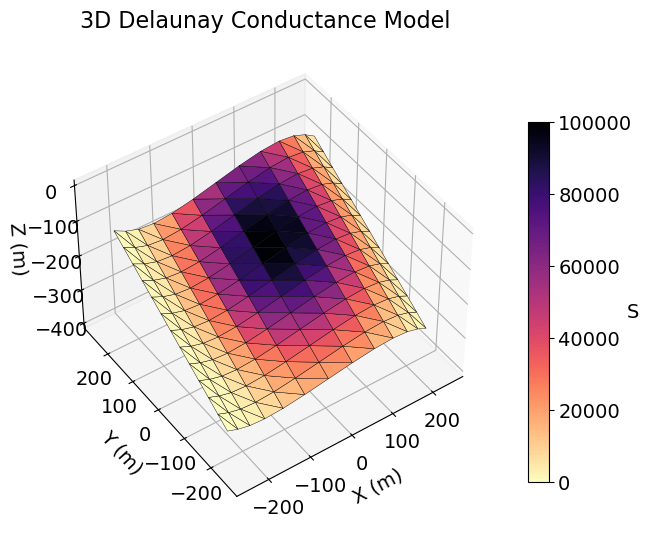

In [19]:
poly_tris = Poly3DCollection(dlny_pts_3d[dlny_simps])
poly_colors = cmap(norm(dlny_conductance_model))
poly_tris.set_facecolor(poly_colors)
poly_tris.set_edgecolor('black')  # Set to 'none' if you want a smooth look without wireframes
poly_tris.set_linewidth(0.3)

fig = plt.figure(figsize=(7, 6))
ax1 = fig.add_axes([0.1, 0.1, 0.75, 0.85], projection="3d")
ax2 = fig.add_axes([0.85, 0.2, 0.03, 0.6])

ax1.add_collection3d(poly_tris)
ax1.set_box_aspect(aspect=None, zoom=0.85)
ax1.set_xlabel("X (m)", labelpad=10)
ax1.set_ylabel("Y (m)", labelpad=10)
ax1.set_zlabel("Z (m)", labelpad=10)
ax1.set_title("3D Delaunay Conductance Model", fontsize=16, pad=-20)
ax1.view_init(elev=45.0, azim=-125)

cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.magma_r
)
cbar.set_label("S", rotation=0, labelpad=0)

plt.show()

## Defining a (Tree) Mesh

The approach for generating suitable meshes was presented in the [3D Forward Simulation for Sheet-Like Conductors Part 1](fwd_utem_hierarchical_3d_part_1.ipynb) tutorial.

**Tutorial mesh:** Here, a minimum cell width of 25 m is used in proximity of the transmitter loop to accurately capture the geometry of the primary field. A minimum cell width of 25 m is used near the receivers to minimize interpolation error. And a minimum cell width of 25 m is used in the region where a sheet-like conductor is modeled in order to capture the diffusion of eddy currents and secondary magnetic fields. A discretization of 50 m is used for the remainder of the survey region. The host has a conductivity of 1e-3 S/m. Since the diffusion distance for the host is so large at the earliest time channel, the cell size within the survey region is more driven by geometry of the primary field. The largest diffusion distance is ~20,000 m. So the width of the padding region was set to 40,000 m in all directions.

In [20]:
air_conductivity = 1e-8
host_conductivity = 1e-3

In [21]:
host_diffusion_distance = 1260 * np.sqrt(time_channels / host_conductivity)
print("HOST: {}".format(host_diffusion_distance))

HOST: [ 1760.90353228  2490.29365738  3521.80706456  4980.58731477
  7043.61412912  9961.17462953 14087.22825825 19922.34925906]


In [22]:
# Instantiate OcTree mesh
dh = 25.0
L = 80000.0
nbc = 2 ** int(np.round(np.log(L / dh) / np.log(2.0)))
h = [(dh, nbc)]
mesh = TreeMesh([h, h, h], origin="CCC", diagonal_balance=True)

# Shift vertically so top same as maximum topography
mesh.origin += np.r_[0.0, 0.0, z_topo.min()]

In [23]:
# Discretize around transmitter
n_seg = np.shape(xyz_loop)[0] - 1
n_pts_per_seg = 20

pts = [
    np.c_[
        np.linspace(xyz_loop[ii, 0], xyz_loop[ii + 1, 0], n_pts_per_seg),
        np.linspace(xyz_loop[ii, 1], xyz_loop[ii + 1, 1], n_pts_per_seg),
        np.linspace(xyz_loop[ii, 2], xyz_loop[ii + 1, 2], n_pts_per_seg),
    ]
    for ii in range(n_seg)
]

pts = np.vstack(pts)
mesh.refine_points(pts, level=-1, padding_cells_by_level=[4, 3, 2, 2], finalize=False)

In [24]:
# Discretize around borehole receivers
mesh.refine_points(receiver_locations, level=-1, padding_cells_by_level=[3, 3], finalize=False)

In [25]:
# Discretization for core survey region
pts = ndgrid(
    np.r_[-700, 700], np.r_[-700, 700], np.r_[z_topo.min() - 800, z_topo.min() + 50]
)

mesh.refine_bounding_box(pts, -2, padding_cells_by_level=[0, 4, 4], finalize=False)

In [26]:
# Discretize surface topography
inds = (np.abs(topo_xyz[:, 0]) < 1400.0) & (np.abs(topo_xyz[:, 1]) < 1400.0)

mesh.refine_surface(
    topo_xyz[inds, :], -2, padding_cells_by_level=[1, 2], finalize=False
)

In [27]:
# Discretize in the region of the sheet-like conductor
pts = ndgrid(
    np.r_[-300, 300], np.r_[-300, 300], np.r_[-400, 0]
)

mesh.refine_bounding_box(pts, -1, padding_cells_by_level=[0, 4, 4], finalize=False)

In [28]:
mesh.finalize()

In [29]:
mesh.n_cells

77939

## Defining the Background Conductivity

The role of the background conductivity was discussed in the [3D Forward Simulation for Sheet-Like Conductors Part 1](fwd_utem_hierarchical_3d_part_1.ipynb) tutorial. **For this tutorial,** all cells below the discrete surface topography are assigned a conductivity of 1e-3 S/m and all air cells are assigned a conductivity of 1e-8 S/m. So, the background conductivity is an (n_cells,) [numpy.ndarray](xref:numpy#numpy.ndarray).

```{admonition} Complex background conductivity
:class: note
The hierarchical finite volume approach allows complete freedom to include 3D structure in the background conductivity. We are not limited to a homogeneous background.
```

```{admonition} Including conductivity in the model
:class: note
Cell conductivities can be included in the model but implementation becomes more complicated. The model would contain two parameter types and the user would need to construct a appropriate mappings for multiple hierarchical electrical properties.
```

In [30]:
# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_xyz)

# Define the background conductivity (n_cells,)
background_conductivity = air_conductivity * np.ones(mesh.n_cells)
background_conductivity[active_cells] = host_conductivity

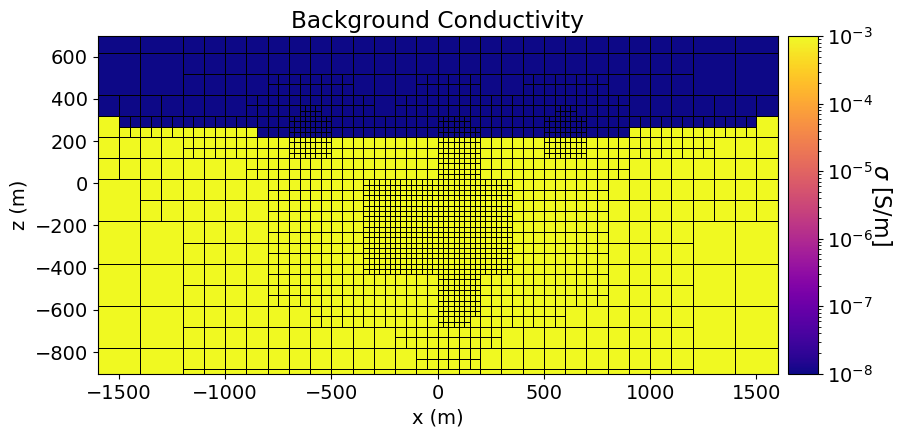

In [31]:
# Plot the background conductivity
fig = plt.figure(figsize=(10, 4.5))

norm = LogNorm(vmin=background_conductivity.min(), vmax=background_conductivity.max())

ax1 = fig.add_axes([0.15, 0.15, 0.68, 0.75])
mesh.plot_slice(
    background_conductivity,
    ax=ax1,
    normal="Y",
    ind=int(len(mesh.h[1]) / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
    grid_opts={"lw": 0.5, "color": 'k'}
)
ax1.set_title("Background Conductivity")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")
ax1.set_xlim([-1600, 1600])
ax1.set_ylim([z_topo.max() - 1200, z_topo.max() + 400])

ax2 = fig.add_axes([0.84, 0.15, 0.03, 0.75])
cbar = mpl.colorbar.ColorbarBase(
    ax2, cmap=mpl.cm.plasma, norm=norm, orientation="vertical"
)
cbar.set_label(r"$\sigma$ [S/m]", rotation=270, labelpad=15, size=16)

## Mapping the Delaunay Model to the Mesh

We require a mapping from the Delaunay conductance model to the conductances for all mesh faces. Provided the geometry of the Delaunay surface is fixed, this is a linear mapping. Here, we use the ``get_face_projection_simplex`` utility function to construct the linear operator that maps from the Delaunay conductance model to all mesh faces. Then we use the [simpeg.maps.LinearMap](xref:simpeg#simpeg.maps.LinearMap) class to define a SimPEG mapping object for the simulation.

```{admonition} Log-conductance model
:class: note
Since conductances can span multiple orders of magnitude, it is possible to define the parameters of the Delaunay model as log-conductances. In this case, you would need to apply the [simpeg.maps.ExponentMap](xref:simpeg#simpeg.maps.ExponentialMap) before the mapping that projects conductances to mesh faces.
```

In [32]:
# Construct the linear operator
P = get_face_projection_simplex(mesh, dlny_pts_3d, dlny_simps)

In [33]:
# Define the SimPEG mapping
dlny_conductance_map = maps.LinearMap(A=P)

Below, map the Delaunay conductances model to the mesh and show all non-zero conductances projected to mesh faces.

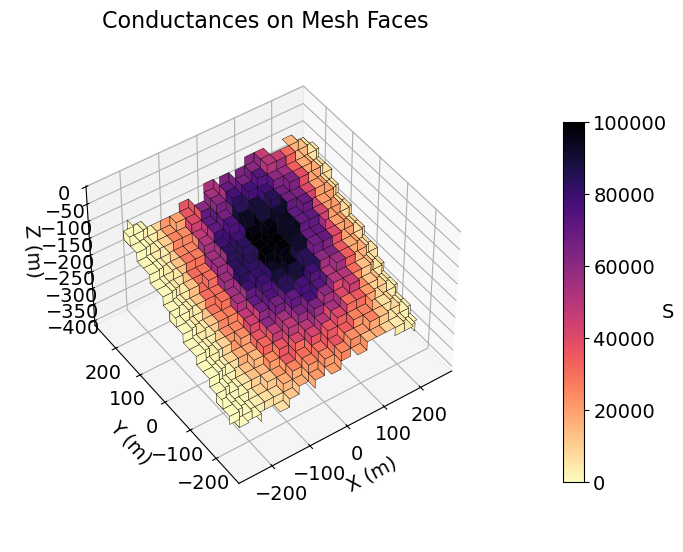

In [34]:
norm = mpl.colors.Normalize(vmin=0, vmax=1e5)

temp_conds = P @ dlny_conductance_model  # map model to mesh faces
temp_inds = temp_conds > 0.              # find all non-zero values

# Generate all squares in 3D
plate_faces = mesh.faces[temp_inds, :]
plate_normals = mesh.face_normals[temp_inds, :]
n_plate_faces = sum(plate_faces)

poly_pts = np.expand_dims(plate_faces, axis=1)
poly_pts = np.tile(poly_pts, (1, 4, 1))
for ii, nrml in enumerate(plate_normals):
    if nrml[0] == 1.:
        poly_pts[ii, :, :] += dh/2 * np.array([
            [0, -1, -1], [0, 1, -1], [0, 1, 1], [0, -1, 1]
        ])
    elif nrml[1] == 1.:
        poly_pts[ii, :, :] += dh/2 * np.array([
            [-1, 0, -1], [1, 0, -1], [1, 0, 1], [-1, 0, 1]
        ])
    elif nrml[2] == 1.:
        poly_pts[ii, :, :] += dh/2 * np.array([
            [-1, -1, 0], [1, -1, 0], [1, 1, 0], [-1, 1, 0]
        ])

# Plot
poly_faces = Poly3DCollection(poly_pts)
poly_colors = cmap(norm(temp_conds[temp_inds]))
poly_faces.set_facecolor(poly_colors)
poly_faces.set_edgecolor('black')  # Set to 'none' if you want a smooth look without wireframes
poly_faces.set_linewidth(0.3)

fig = plt.figure(figsize=(7, 6))
ax1 = fig.add_axes([0.05, 0.1, 0.75, 0.85], projection="3d")
ax2 = fig.add_axes([0.85, 0.2, 0.03, 0.6])

ax1.add_collection3d(poly_faces)
ax1.set_box_aspect(aspect=None, zoom=0.8)
ax1.set_xlabel("X (m)", labelpad=10)
ax1.set_ylabel("Y (m)", labelpad=10)
ax1.set_zlabel("Z (m)", labelpad=10)
ax1.set_title("Conductances on Mesh Faces", fontsize=16, pad=-20)
ax1.view_init(elev=45.0, azim=-125)

cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.magma_r
)
cbar.set_label("S", rotation=0, labelpad=0)

plt.show()

## Defining the Time-Stepping

Here, we define the time-stepping that is used for the forward simulation. We reuse the time-stepping from the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) and [3D Forward Simulation for Sheet-Like Conductors Part 1](fwd_utem_hierarchical_3d_part_1.ipynb) tutorials. The resulting time-steps are illustrated below.

In [35]:
# Minimum time step based on earliest time channel
n_steps = 20
min_dt = time_channels[0] / 20.0
min_dt = round(min_dt, 1 - int(np.floor(np.log10(min_dt))) - 1)

# Find times where step length is increased
tc_min = np.min(time_channels)
tc_max = np.max(time_channels)
ti = [None, tc_min, 6 * tc_min, 36 * tc_min]
dt = [period / 60, min_dt, 6 * min_dt, 36 * min_dt]

In [36]:
# Define all discrete times
wave_times = np.arange(-0.75 * period, 0, dt[0])
wave_times = np.r_[wave_times, np.arange(0, ti[1] + dt[1], dt[1])]
wave_times = np.r_[wave_times, np.arange(wave_times[-1] + dt[2], ti[2] + dt[2], dt[2])]
wave_times = np.r_[wave_times, np.arange(wave_times[-1] + dt[3], ti[3] + dt[3], dt[3])]
wave_times = np.r_[
    wave_times, np.arange(wave_times[-1] + dt[0], tc_max + 2 * dt[0], dt[0])
]

In [37]:
# Take difference to obtain time steps
time_steps = np.diff(wave_times)

# Initial time for the simulation
t0 = wave_times[0]

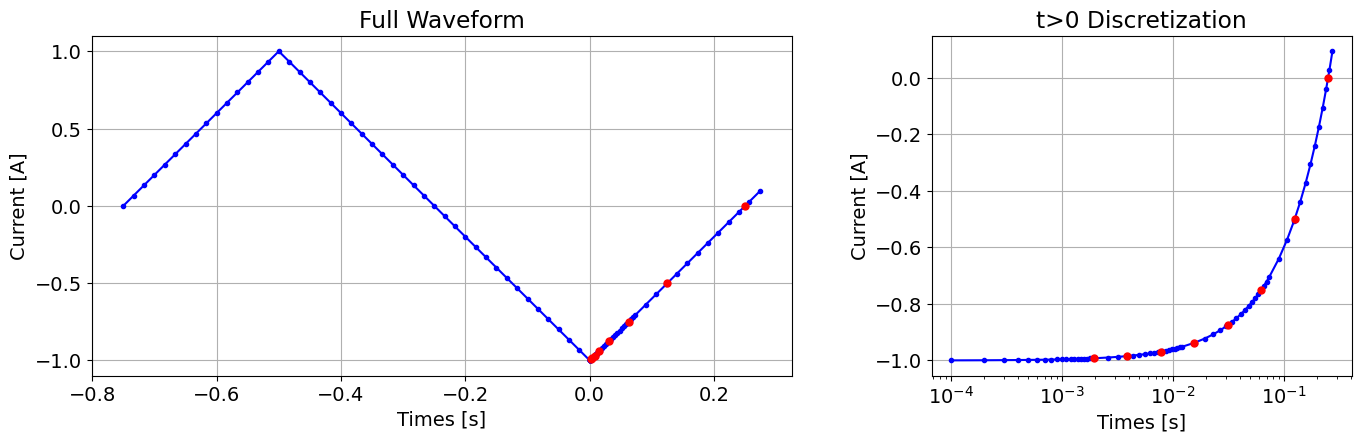

In [38]:
fig = plt.figure(figsize=(14, 4))

ax1 = fig.add_axes([0.1, 0.1, 0.5, 0.85])
ax1.plot(
    wave_times,
    [utem_waveform.eval(t) for t in wave_times],
    "b-o",
    markersize=3
)
ax1.plot(
    time_channels,
    [utem_waveform.eval(t) for t in time_channels],
    "ro",
    markersize=5
)
ax1.grid()
ax1.set_xlabel("Times [s]")
ax1.set_ylabel("Current [A]")
ax1.set_title("Full Waveform")

ax2 = fig.add_axes([0.7, 0.1, 0.3, 0.85])
plot_times = np.logspace(np.log10(time_channels.min()), np.log10(time_channels.max()))
k = wave_times > 0.0
ax2.semilogx(
    wave_times[k],
    [utem_waveform.eval(t) for t in wave_times[k]],
    "b-o",
    markersize=3
)
ax2.semilogx(
    time_channels,
    [utem_waveform.eval(t) for t in time_channels],
    "ro",
    markersize=5
)
ax2.grid()
ax2.set_xlabel("Times [s]")
ax2.set_ylabel("Current [A]")
ax2.set_title("t>0 Discretization")

plt.show()

## Simulating the Data

#### Defining the Simulation

Here, we define the simulation using the same approach as in the [3D Forward Simulation for Sheet-Like Conductors Part 1](fwd_utem_hierarchical_3d_part_1.ipynb) tutorials. Again, we use `sigma` to set and fix the cell conductivities to the values for our background conductivity. Our model parameters are the face conductances for all mesh faces, so we use `face_conductance_map` to set the mapping. Since wire-like structures are not considered, we do not set `edge_integrated_conductance` or `edge_integrated_conductance_map`.

In [39]:
simulation_dlny = tdem.simulation.Simulation3DHierarchicalElectricField(
    mesh,
    survey=survey,
    sigma=background_conductivity,
    face_conductance_map=dlny_conductance_map,
    solver=get_default_solver()
)
simulation_dlny.time_steps = time_steps
simulation_dlny.t0 = t0

#### Predicting the Data

In [40]:
dpred_dlny = simulation_dlny.dpred(dlny_conductance_model)

## Plotting Primary Reduced Data

Here, we plot the primary reduced representation of the predicted data. Our method for generating primary reduced data is explained in the  [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial.

#### Generating Numerical Primary Field Data

We currently have total field data that were collected during the transmitter's on-time. Here, we compute a numerical primary field that can be subtracted to obtain secondary field data. Depending on how we have parameterized the Delaunay conductance model, we may not be able to reuse the hierarchical simulation class to simulate the numerical primary field. Here, we use the regular [Simulation3DElectricField](xref:simpeg#simpeg.electromagnetics.time_domain.simulation.Simulation3DElectricField) simulation class, who input model parameters are the cell conductivities.

In [41]:
simulation_vacuum = tdem.simulation.Simulation3DElectricField(
    mesh,
    survey=survey,
    sigmaMap=maps.IdentityMap(),
    solver=get_default_solver()
)
simulation_vacuum.time_steps = time_steps
simulation_vacuum.t0 = t0

# Define a vacuum background conductivity
vacuum_conductivity = air_conductivity * np.ones_like(background_conductivity)

# Simulate the fields
dpred_0 = simulation_vacuum.dpred(vacuum_conductivity)

#### Generating Primary Reduced Data

In [42]:
# Reshape predicted data vectors to arrays and convert to b-field representation
n_comp = 3  # Simulated x, y and z components
n_rx = np.shape(receiver_locations)[0]  # number of receiver locations
n_times = len(time_channels)  # number of time channels

b_dlny = (period / 4) * np.reshape(dpred_dlny, (n_comp, n_times, n_rx))
b_0 = (period / 4) * np.reshape(dpred_0, (n_comp, n_times, n_rx))

In [43]:
# Compute the absolute value of the primary b-field
b_p = computeH0(xyz_loop, receiver_locations)  # list with x, y and z component
b_p = mu_0 * np.sqrt(b_p[0]**2 + b_p[1]**2 + b_p[2]**2)

In [44]:
u_dlny = 100 * (b_dlny[0, :, :] - b_0[0, :, :]) / b_p
v_dlny = 100 * (b_dlny[1, :, :] - b_0[1, :, :]) / b_p
a_dlny = 100 * (b_dlny[2, :, :] - b_0[2, :, :]) / b_p

data_dlny = [u_dlny, v_dlny, a_dlny]

#### Plotting Primary Reduced Data

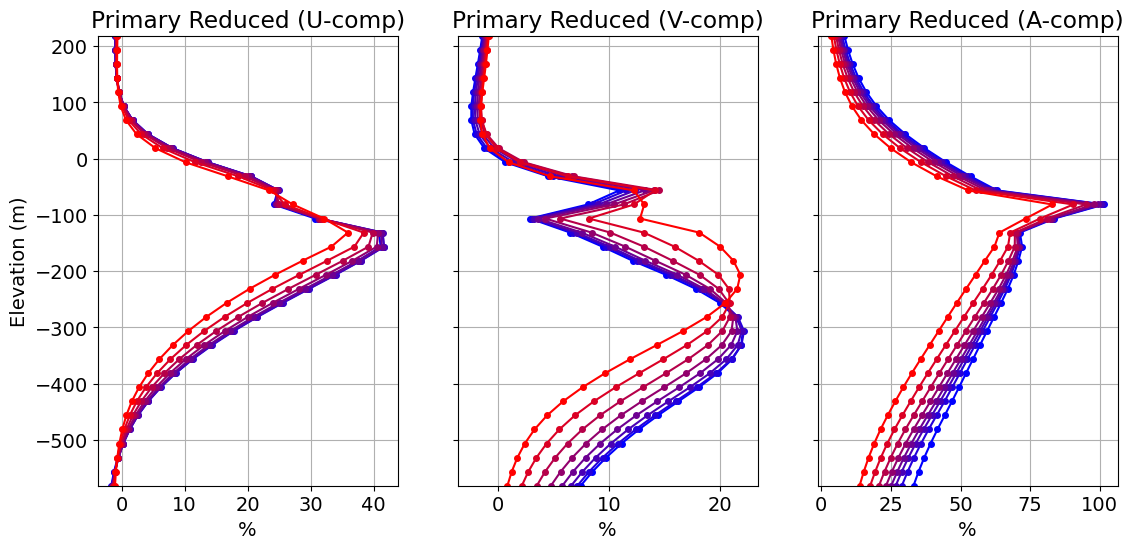

In [45]:
fig = plt.figure(figsize=(12, 6))
ax1 = [fig.add_axes([0.05 + 0.3 * ii, 0.2, 0.25, 0.75]) for ii in range(0, 3)]

comp_list = ["U", "V", "A"]

for ii in range(0, 3):
    d_temp = data_dlny[ii]

    for jj in range(n_times):
        ax1[ii].plot(
            d_temp[jj, :],
            receiver_locations[:, 2],
            marker="o",
            color=[jj / (n_times - 1), 0, 1 - jj / (n_times - 1)],
            markersize=4,
            label="_nolegend_",
        )

    ax1[ii].grid()
    ax1[ii].ticklabel_format(axis="both", scilimits=(0, 3))
    ax1[ii].set_xlabel("%")
    ax1[ii].set_ylim([s_min, s_max])
    if ii == 0:
        ax1[ii].set_ylabel("Elevation (m)")
    else:
        ax1[ii].set_yticklabels([])
    ax1[ii].set_title("Primary Reduced ({}-comp)".format(comp_list[ii]))

plt.show(fig)